# Лабораторная работа 2. Обучение с учителем. Задача регрессии

In [273]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from math import sqrt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

### Загрузка данных

In [274]:
data = pd.read_csv('../data/final_data_diamonds.csv')
data.drop(['Unnamed: 0'], axis=1, inplace=True)

### Первый шаг: выделение целевого признака и предикторов

In [275]:
y = data["price"]
X = data.drop(["price"], axis=1)
y

0         326
1         326
2         327
3         334
4         335
         ... 
53935    2757
53936    2757
53937    2757
53938    2757
53939    2757
Name: price, Length: 53940, dtype: int64

In [276]:
X

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,4,5,1,61.5,55,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...
53935,0.72,4,6,2,60.8,57,5.75,5.76,3.50
53936,0.72,1,6,2,63.1,55,5.69,5.75,3.61
53937,0.70,2,6,2,62.8,60,5.66,5.68,3.56
53938,0.86,3,2,1,61.0,58,6.15,6.12,3.74


### Второй шаг: разделение данных на обучающую и тестовую выборки

In [277]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [278]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((43152, 9), (43152,), (10788, 9), (10788,))

Итак, данные предобработаны, целевой признак выделен, имеются обучающая и тестовая выборка. Мы готовы приступить к обучению.

### Линейная регрессия (Linear Regression). Постановка задачи

In [279]:
lr = LinearRegression().fit(X_train, y_train)
lr.predict(X_test)

array([ 1756.6194731 ,  3270.20583988,  1311.07960053, ...,
        1984.2251711 , 13693.07287899,  4895.10334986], shape=(10788,))

In [280]:
y_pred = lr.predict(X_test)

In [ ]:
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lr.score(X_test, y_test):.2f}')

MAE: 800.30
MSE: 1445325.64
RMSE: 1202.22
MAPE: 0.66


ValueError: y_true and y_pred have different number of output (9!=1)

In [ ]:
len(lr.coef_)
lr.coef_

array([10896.74303295,   125.31330212,   322.93073106,   497.44848942,
         -66.73284912,   -23.27039691, -1499.62863259,   727.96868294,
        -223.92532581])

In [ ]:
# L1
ridge = Ridge(alpha=0.5).fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {r2_score(X_test, y_test):.2f}')
ridge.coef_

MAE: 802.31
MSE: 1443581.21
RMSE: 1201.49
MAPE: 0.65


NameError: name 'r2_score' is not defined

In [ ]:
# L2
lasso = Lasso(alpha=0.5).fit(X_train, y_train)
y_pred = lasso.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lasso.score(X_test, y_test):.2f}')
lasso.coef_

MAE: 802.69
MSE: 1443643.31
RMSE: 1201.52
MAPE: 0.65
R^2: 0.91


array([10836.14725115,   124.01290593,   322.39723608,   498.07346149,
         -70.85277132,   -24.00201878, -1336.84076586,   543.95808691,
        -150.31707842])

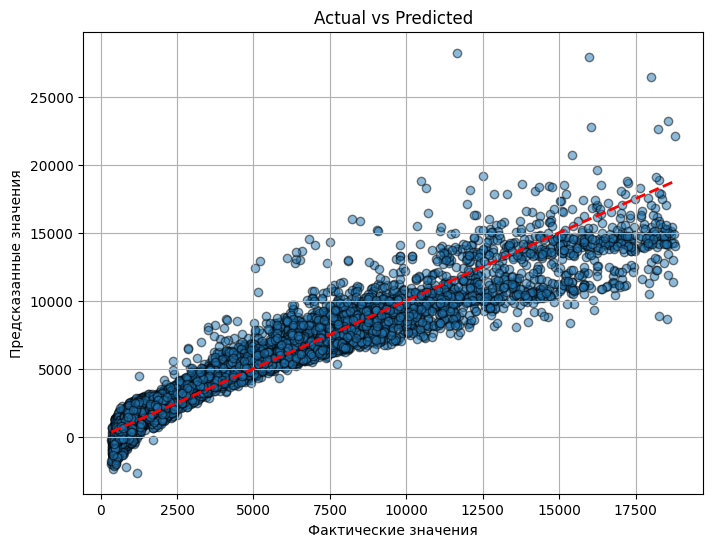

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()

In [ ]:
parameters = {'alpha': np.arange(0, 1, 0.1)}    

In [ ]:
ridge_optimal = GridSearchCV(Ridge(), parameters).fit(X_train, y_train)
ridge_optimal.best_params_

{'alpha': np.float64(0.9)}

In [ ]:
ridge_optimal = RandomizedSearchCV(Ridge(), parameters).fit(X_train, y_train)
ridge_optimal.best_params_

{'alpha': np.float64(0.9)}

In [ ]:
ridge_final = Ridge(alpha=0.9).fit(X_train, y_train)
y_pred_ridge = ridge_final.predict(X_test)

In [ ]:
# L1
ridge = Ridge(alpha=0.9).fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lr.score(X_test, y_test):.2f}')
ridge.coef_

MAE: 802.44
MSE: 1443613.26
RMSE: 1201.50
MAPE: 0.65
R^2: 0.91


array([10873.5331388 ,   125.30538494,   322.77219627,   497.55731244,
         -66.2941761 ,   -23.24125372, -1484.71341566,   722.90703713,
        -224.4706261 ])

In [ ]:
# L2
lasso = Lasso(alpha=0.9).fit(X_train, y_train)
y_pred = lasso.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lasso.score(X_test, y_test):.2f}')
lasso.coef_

MAE: 803.22
MSE: 1444085.19
RMSE: 1201.70
MAPE: 0.65
R^2: 0.91


array([10787.79202968,   122.97362208,   321.97056301,   498.57132358,
         -74.16644475,   -24.58643243, -1206.94909937,   396.87097017,
         -91.16154602])